# Spark OCR example of recognize text in natural scene

## Install spark-ocr python packge
Need specify path to `spark-ocr-assembly-[version].jar` or `secret`

In [1]:
secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

version = secret.split("-")[0]

In [2]:
%%bash
if python -c 'import google.colab' &> /dev/null; then
    echo "Run on Google Colab!"
    echo "Install Open JDK"
    sudo apt update
    apt-get install -y openjdk-8-jdk-headless -qq > /dev/null
    java -version
fi

In [3]:
import sys
import os

if 'google.colab' in sys.modules:
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
  os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [4]:
# install from PYPI using secret
# %pip install spark-ocr==$version+spark30 --extra-index-url=https://pypi.johnsnowlabs.com/$secret --upgrade

In [5]:
# or install from local path
# %pip install ../../python/dist/spark-ocr-1.9.0.spark24.tar.gz

## Initialization of spark session

In [6]:
from pyspark.sql import SparkSession
from sparkocr import start
import os

if license:
    os.environ['JSL_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.4.0
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2



## Imports

In [7]:
from pyspark.ml import PipelineModel
from pyspark.sql import functions as F

from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import display_image
from sparkocr.metrics import score

## Define OCR transformers

In [8]:
# Read binary as image
binary_to_image = BinaryToImage()
binary_to_image.setInputCol("content")
binary_to_image.setOutputCol("image")

# Scale image
scaler = ImageScaler()
scaler.setInputCol("image")
scaler.setOutputCol("scaled_image")
scaler.setScaleFactor(2.0)

# Binarize using adaptive tresholding
binarizer = ImageAdaptiveThresholding()
binarizer.setInputCol("scaled_image")
binarizer.setOutputCol("binarized_image")
binarizer.setBlockSize(71)
binarizer.setOffset(65)

remove_objects = ImageRemoveObjects()
remove_objects.setInputCol("binarized_image")
remove_objects.setOutputCol("cleared_image")
remove_objects.setMinSizeObject(400)
remove_objects.setMaxSizeObject(4000)

# Apply morphology opening
morpholy_operation = ImageMorphologyOperation()
morpholy_operation.setKernelShape(KernelShape.DISK)
morpholy_operation.setKernelSize(3)
morpholy_operation.setOperation("closing")
morpholy_operation.setInputCol("cleared_image")
morpholy_operation.setOutputCol("corrected_image")

# Run OCR
ocr = ImageToText()
ocr.setInputCol("corrected_image")
ocr.setOutputCol("text")
ocr.setConfidenceThreshold(50)
ocr.setIgnoreResolution(False)

# OCR pipeline
pipeline = PipelineModel(stages=[
    binary_to_image,
    scaler,
    binarizer,
    remove_objects,
    morpholy_operation,
    ocr
])

## Read image with noised background

In [9]:
import pkg_resources
imagePath = pkg_resources.resource_filename('sparkocr', 'resources/ocr/images/natural_scene.jpeg')
image_df = spark.read.format("binaryFile").load(imagePath).cache()
image_df.show()

+--------------------+--------------------+------+--------------------+
|                path|    modificationTime|length|             content|
+--------------------+--------------------+------+--------------------+
|file:/home/jose/....|2026-06-22 17:10:...|133271|[FF D8 FF DB 00 8...|
+--------------------+--------------------+------+--------------------+



## Run OCR pipelines and show results

In [10]:
result = pipeline.transform(image_df).cache()

result.select("text").show()

+---------------+
|           text|
+---------------+
|MIDDLEBOROUGH\n|
+---------------+



## Display image for each stage

Original: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/natural_scene.jpeg

    Image #0:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/natural_scene.jpeg
    Resolution: 0 dpi
    Width: 640 px
    Height: 480 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


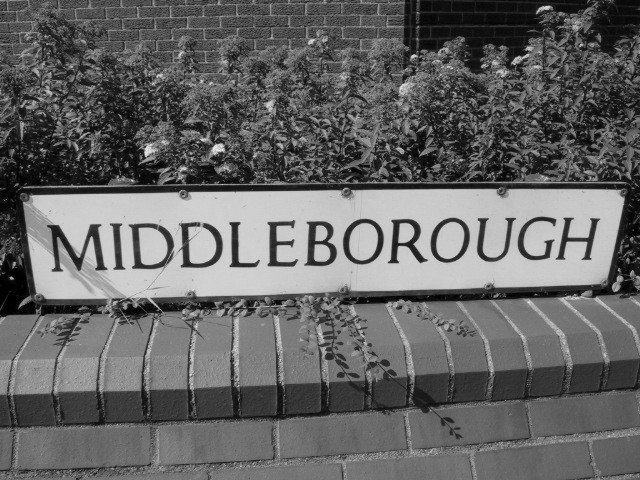

Binarized

    Image #0:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/natural_scene.jpeg
    Resolution: 0 dpi
    Width: 1280 px
    Height: 960 px
    Mode: ImageType.TYPE_BYTE_BINARY
    Number of channels: 1


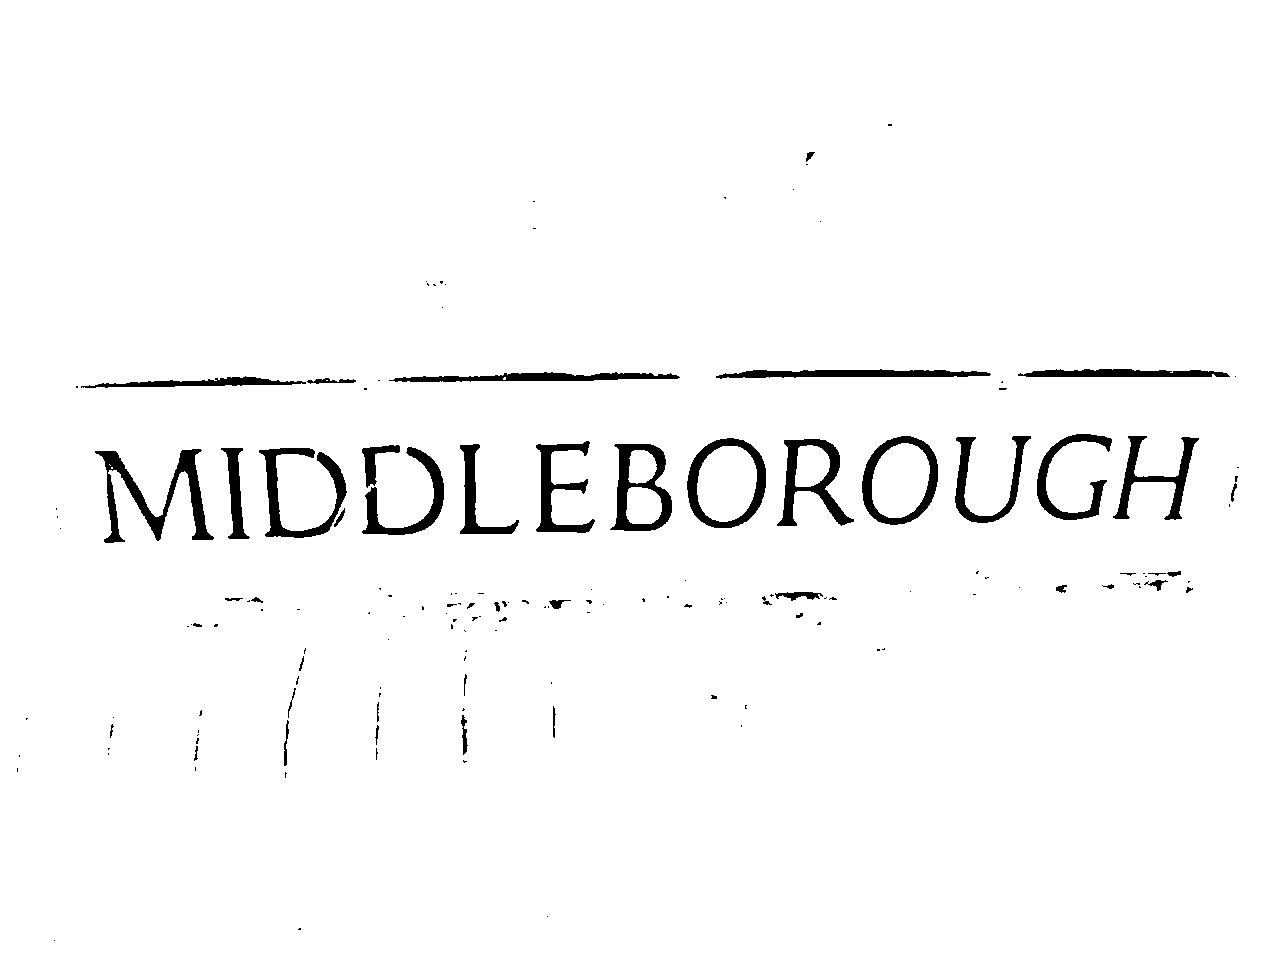

Removing objetcts

    Image #0:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/natural_scene.jpeg
    Resolution: 0 dpi
    Width: 1280 px
    Height: 960 px
    Mode: ImageType.TYPE_BYTE_BINARY
    Number of channels: 1


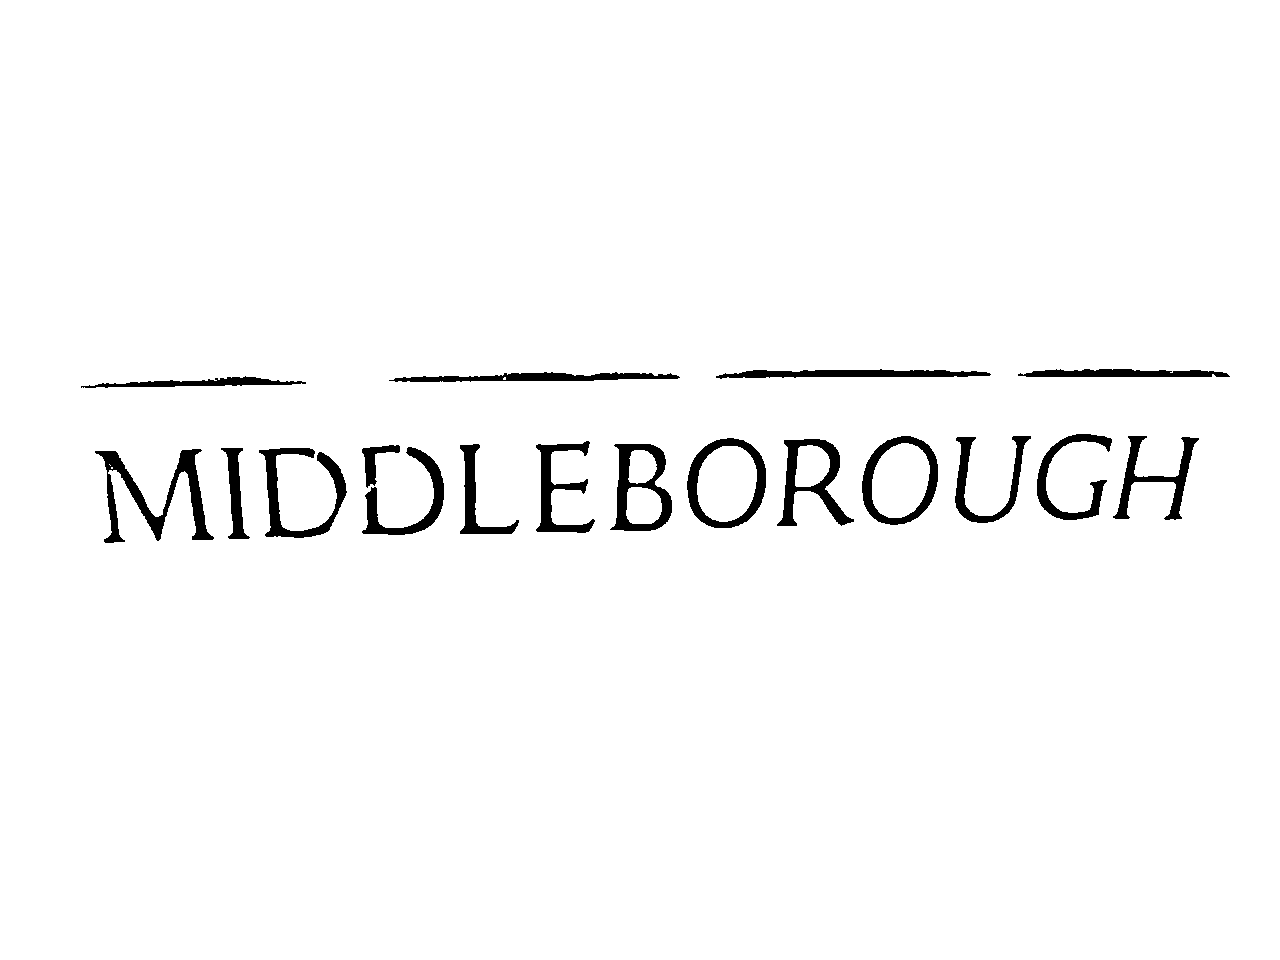

Morphology closing

    Image #0:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/natural_scene.jpeg
    Resolution: 0 dpi
    Width: 1280 px
    Height: 960 px
    Mode: ImageType.TYPE_BYTE_BINARY
    Number of channels: 1


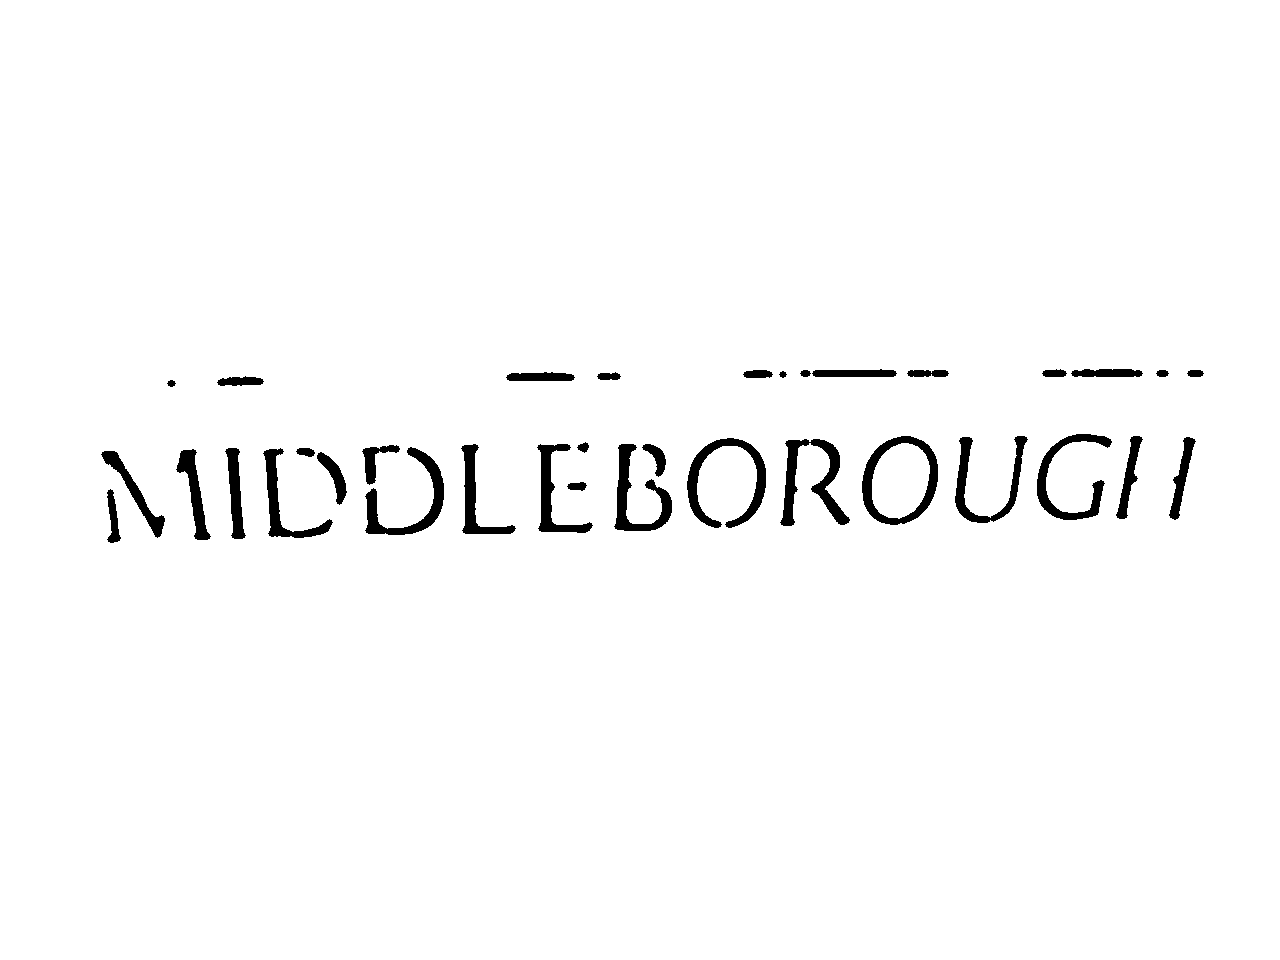

In [11]:
for r in result.distinct().collect():
    print("Original: %s" % r.path)
    display_image(r.image)
    print("Binarized")
    display_image(r.binarized_image)
    print("Removing objetcts")
    display_image(r.cleared_image)
    print("Morphology closing")
    display_image(r.corrected_image)